In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

Project Root: /Users/marekkiedrowicz/Documents/GitHub/macro-portfolio-lab
Data Directory: /Users/marekkiedrowicz/Documents/GitHub/macro-portfolio-lab/data


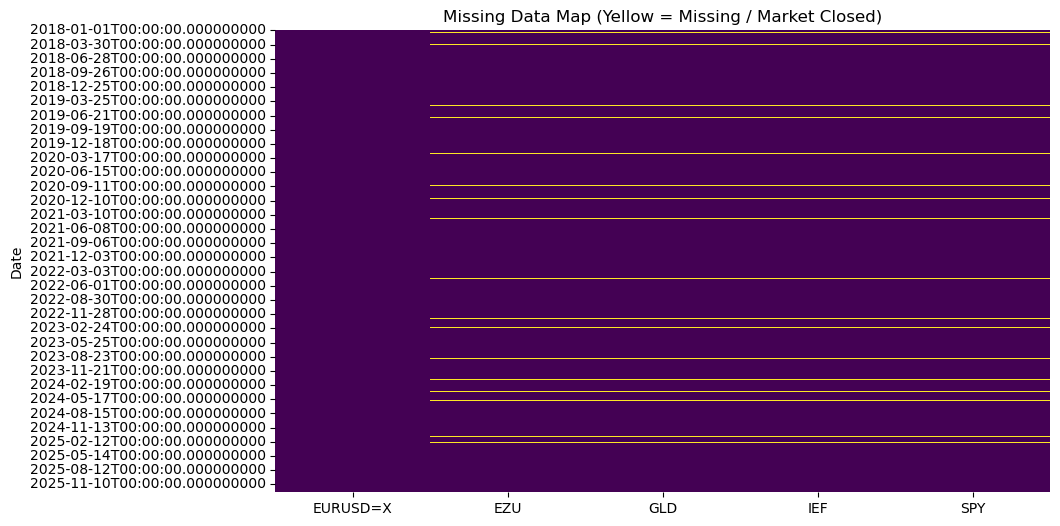

Total rows: 2084
Rows with at least one missing value: 76
Percent of 'dirty' rows: 3.6%


In [2]:
# Connect notebook to the 'src' folder
current_dir = Path(os.getcwd())
src_dir = current_dir.parent / "src"
sys.path.append(str(src_dir))

from data import load_prices, clean_prices, DATA_DIR

# 1. Load the RAW data (before cleaning)
# Bypass the 'clean_prices' function for a moment to see the mess
raw_df = load_prices("market_prices.csv")

# 2. Visualize Missing Data (The "Matrix" Plot)
plt.figure(figsize=(10, 6))
# isna() returns True (1) if missing, False (0) if present
sns.heatmap(raw_df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Data Map (Yellow = Missing / Market Closed)")
plt.show()

# 3. Calculate "raggedness"
print("Total rows:", len(raw_df))
print("Rows with at least one missing value:", raw_df.isna().any(axis=1).sum())
print(f"Percent of 'dirty' rows: {raw_df.isna().any(axis=1).sum() / len(raw_df):.1%}")

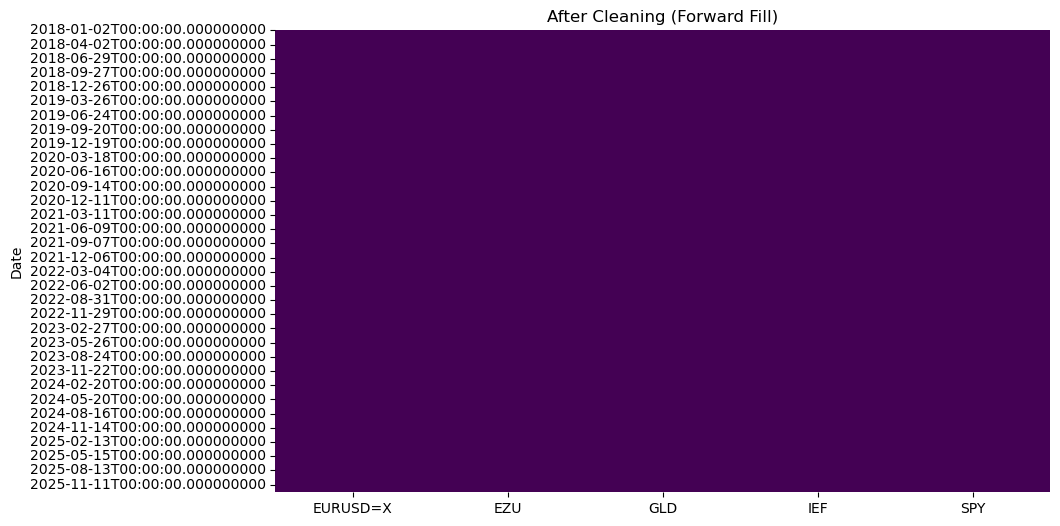

Remaining dirty rows: 0


In [3]:
# 4. Apply the Cleaning
df_clean = clean_prices(raw_df)

# 5. Check again
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.isna(), cbar=False, cmap="viridis")
plt.title("After Cleaning (Forward Fill)")
plt.show()

print(f"Remaining dirty rows: {df_clean.isna().any(axis=1).sum()}")